<a href="https://colab.research.google.com/github/sreelakshmisajeevan-854/Anime-Recommendation-System-Using-Cosine-Similarity/blob/main/Anime-Recommendation-System-Using-Cosine-Similarity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# Data Preprocessing:

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Datasets/anime.csv')

In [ ]:
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [ ]:
df.shape

(12294, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [ ]:
df.isnull().sum()

,0
anime_id,0
name,0
genre,62
type,25
episodes,0
rating,230
members,0


In [ ]:
df["genre"] = df["genre"].fillna("Unknown")
df["type"] = df["type"].fillna("Unknown")
df["rating"] = df["rating"].fillna(df["rating"].median())

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


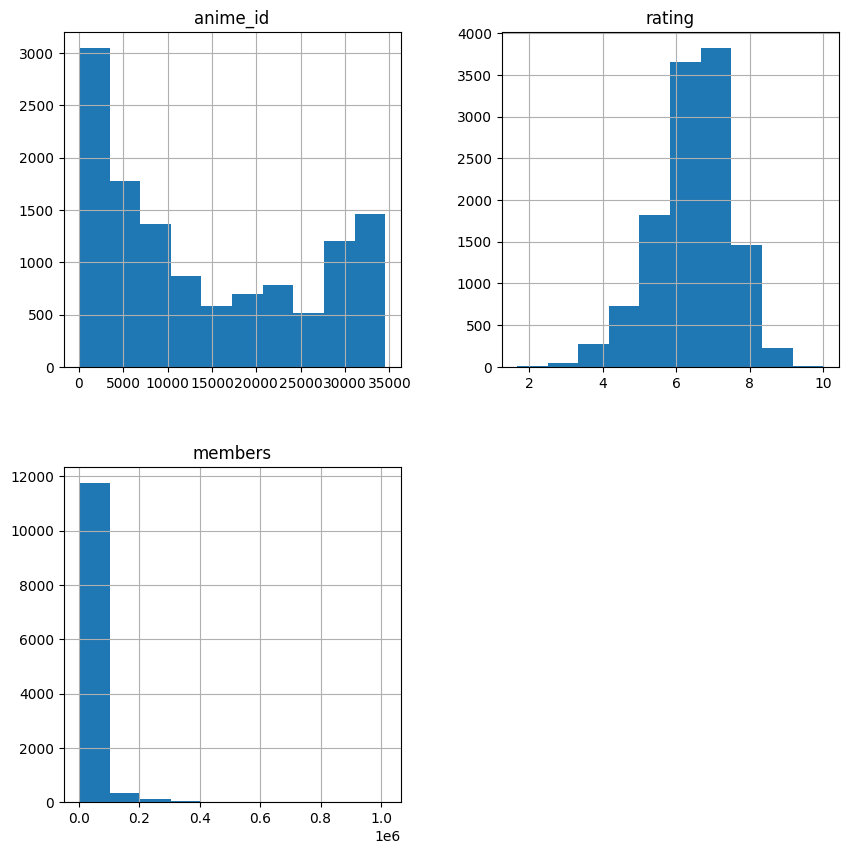

In [ ]:
df.hist(figsize=(10,10))
plt.show()

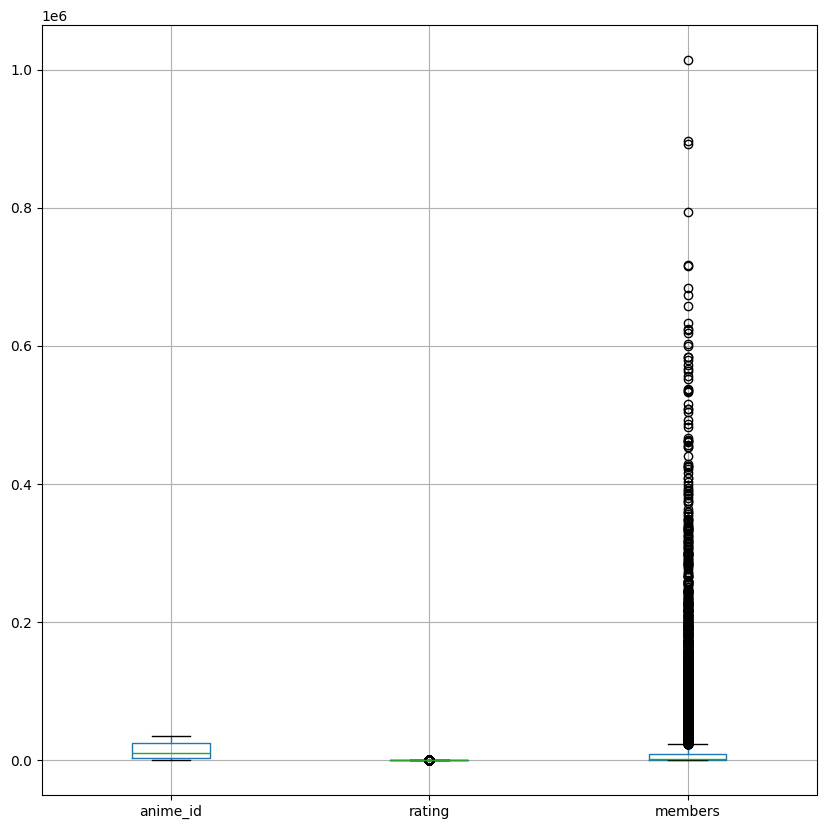

In [ ]:
df.boxplot(figsize=(10,10))
plt.show()

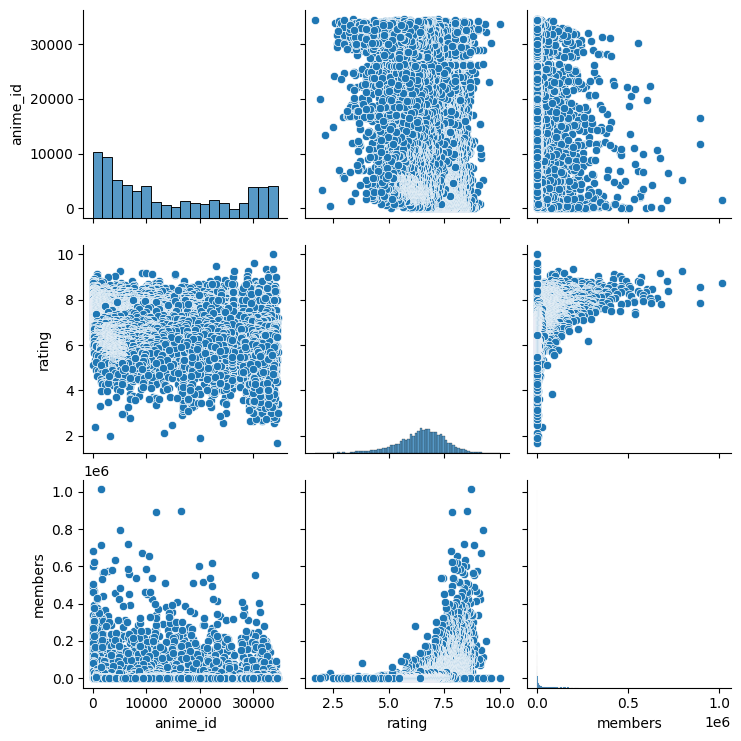

In [ ]:
sns.pairplot(df)
plt.show()

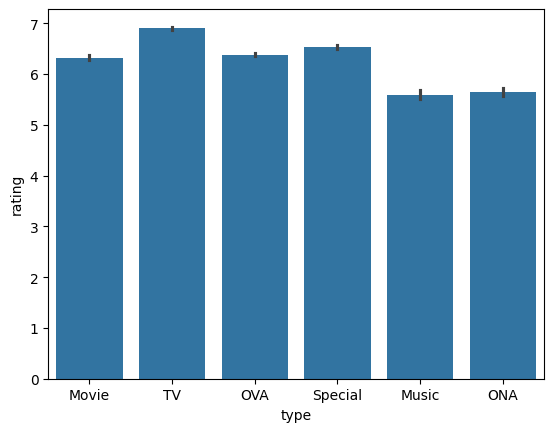

In [ ]:
sns.barplot(x='type',y='rating',data=df)
plt.show()

Inference:

*   The Anime dataset contains 12,294 anime records and 7 attributes. The dataset contains both numerical and categorical variables.
*   Missing values are present in genre, type, and rating. Categorical missing values can be replaced with "Unknown", while missing ratings can be imputed using the median.
*   Rating is more TV compared to others.
*   There are comparitively large variation in members.





# Feature Extraction:

In [ ]:
#Convert genre into numerical representation using TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()
genre_matrix = tfidf.fit_transform(df["genre"])

In [ ]:
#One-hot encode type
type_encoded = pd.get_dummies(df["type"], prefix="type")

In [ ]:
#Since episodes contains values such as "Unknown"
df["episodes"] = pd.to_numeric(df["episodes"], errors="coerce")
df["episodes"] = df["episodes"].fillna(df["episodes"].median())

In [ ]:
#Scaling numerical variables
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numeric_features = scaler.fit_transform(
    df[["rating", "episodes", "members"]]
)

# Recommendation System:

In [ ]:
#Calculate cosine similarity
from sklearn.metrics.pairwise import cosine_similarity
similarity_matrix = cosine_similarity(genre_matrix)

In [ ]:
#Create the recommendation function
def recommend_anime(anime_name, threshold=0.3, n=10):

    index = df[df["name"].str.lower() == anime_name.lower()].index[0]

    similarity_scores = list(enumerate(similarity_matrix[index]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )
    recommendations = []
    for i, score in similarity_scores:
        if i != index and score >= threshold:
            recommendations.append(
                (df.iloc[i]["name"], score)
            )
        if len(recommendations) == n:
            break
    return recommendations

In [ ]:
recommend_anime("Naruto", threshold=0.3, n=10)

[('Boruto: Naruto the Movie', np.float64(1.0)),
 ('Naruto: Shippuuden', np.float64(1.0)),
 ('Boruto: Naruto the Movie - Naruto ga Hokage ni Natta Hi', np.float64(1.0)),
 ('Naruto x UT', np.float64(1.0)),
 ('Naruto: Shippuuden Movie 4 - The Lost Tower', np.float64(1.0)),
 ('Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsugu Mono', np.float64(1.0)),
 ('Naruto Shippuuden: Sunny Side Battle', np.float64(1.0)),
 ('Naruto Soyokazeden Movie: Naruto to Mashin to Mitsu no Onegai Dattebayo!!',
  np.float64(1.0)),
 ('Kyutai Panic Adventure!', np.float64(0.980692123146288)),
 ('Naruto: Shippuuden Movie 6 - Road to Ninja',
  np.float64(0.9471851000728739))]

In [ ]:
recommend_anime("Naruto", threshold=0.1, n=10)

[('Boruto: Naruto the Movie', np.float64(1.0)),
 ('Naruto: Shippuuden', np.float64(1.0)),
 ('Boruto: Naruto the Movie - Naruto ga Hokage ni Natta Hi', np.float64(1.0)),
 ('Naruto x UT', np.float64(1.0)),
 ('Naruto: Shippuuden Movie 4 - The Lost Tower', np.float64(1.0)),
 ('Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsugu Mono', np.float64(1.0)),
 ('Naruto Shippuuden: Sunny Side Battle', np.float64(1.0)),
 ('Naruto Soyokazeden Movie: Naruto to Mashin to Mitsu no Onegai Dattebayo!!',
  np.float64(1.0)),
 ('Kyutai Panic Adventure!', np.float64(0.980692123146288)),
 ('Naruto: Shippuuden Movie 6 - Road to Ninja',
  np.float64(0.9471851000728739))]

In [ ]:
#Compare threshold values
thresholds = [0.1, 0.2, 0.3, 0.5, 0.7]

for threshold in thresholds:

    recommendations = recommend_anime(
        "Mushishi Zoku Shou: Odoro no Michi",
        threshold=threshold,
        n=1200
    )

    print("Threshold:", threshold)
    print("Number of recommendations:", len(recommendations))
    print()

Threshold: 0.1
Number of recommendations: 1200

Threshold: 0.2
Number of recommendations: 1200

Threshold: 0.3
Number of recommendations: 1200

Threshold: 0.5
Number of recommendations: 630

Threshold: 0.7
Number of recommendations: 15



Analysis of the recommendation system
~~~
Strengths:

*   Simple and easy to understand.
*   Does not require user-rating history.
*   Uses the content of the anime, particularly genres.
*   Cosine similarity provides a numerical measure of similarity.The threshold can be adjusted according to how many recommendations are required.

~~~

~~~
Weakness:

*    Recommendations depend heavily on the features used.
*   If only genre is used, anime with similar genres may be recommended even if their ratings or popularity are very different.
*   It does not learn individual user preferences.
*  Very common genres may not provide enough information to distinguish anime.A very high threshold can produce very few recommendations.
~~~

~~~
Areas for improvement:

*   Giving different weights to important features.
*   Using user ratings and viewing history.Using collaborative filtering.
*   Building a hybrid recommendation system combining content-based and collaborative filtering.
*   Combining multiple features rather than relying only on genre.
*   Adding diversity so that recommendations are not all nearly identical.
~~~













The recommendation system successfully identifies similar anime using TF-IDF and cosine similarity. Anime with similar genres receive higher similarity scores and are recommended to the user. Experimenting with different similarity thresholds shows that lower thresholds produce more recommendations, while higher thresholds provide fewer but more relevant recommendations. The main limitation is that the current system relies primarily on genre information and does not consider individual user preferences. The system can be improved by incorporating additional features such as rating, type, episodes, and popularity, as well as user-rating information and collaborative filtering techniques.

Interview Questions:

1.   Can you explain the difference between user-based and item-based collaborative filtering?

 *   User-based collaborative filtering recommends items by finding users who have similar preferences or behavior. For example, if two users have rated many anime similarly and one user likes an anime that the other has not watched, that anime can be recommended to the other user.

 *   Item-based collaborative filtering, on the other hand, finds items that are similar based on the preferences of users. For example, if many users who liked Naruto also liked One Piece, the system can recommend One Piece to someone who likes Naruto. In simple terms, user-based filtering focuses on similar users, while item-based filtering focuses on similar items.


2.   What is collaborative filtering, and how does it work?

Collaborative filtering is a recommendation technique that uses the behavior and preferences of multiple users to recommend items. It does not primarily depend on the content or characteristics of the item; instead, it looks at user-item interactions such as ratings, purchases, views, or watch history. The system identifies patterns among users or items and uses those patterns to predict what a user may like. For example, if users who liked Naruto also frequently liked One Piece, the system may recommend One Piece to a user who likes Naruto. Collaborative filtering can be implemented using either user-based or item-based approaches.